# XGBOOST: training, tuning

in this file we will train our best model , with the best strategy.
but it can underperform since we need to tweak the parameter to find the best performance possible , to reduce the False positives

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import f1_score

from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

In [2]:
df = pd.read_csv("../data/preprocessed/creditcard_Processed.csv")

In [3]:
print(df.shape)

(283726, 31)


# splitting the dataset by 64/20/16

In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

# class weight calculation

In [5]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
scale_pos_weight

np.float64(600.2715231788079)

In [6]:
neg, pos

(np.int64(181282), np.int64(302))

# training

In [7]:
# baseline model trainnig
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [8]:
y_proba = model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_threshold

np.float32(0.97790194)

In [9]:
y_pred = (y_proba >= best_threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nROC-AUC:", roc_auc_score(y_val, y_proba))

print("PR-AUC:", average_precision_score(y_val, y_proba))

Confusion Matrix:
[[45318     2]
 [   14    62]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45320
           1       0.97      0.82      0.89        76

    accuracy                           1.00     45396
   macro avg       0.98      0.91      0.94     45396
weighted avg       1.00      1.00      1.00     45396


ROC-AUC: 0.9804675523760858
PR-AUC: 0.8718498567156029


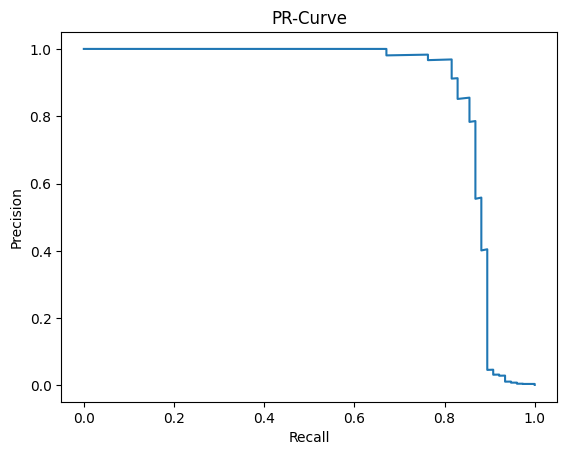

In [10]:
precision, recall, thresholds = precision_recall_curve(y_val, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR-Curve")
plt.show()

# Hyperparameter Tuning

In [11]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

param_dist = {
    "n_estimators": stats.randint(100, 500),
    "max_depth": stats.randint(3, 8),
    "learning_rate": stats.uniform(0.01, 0.2),
    "subsample": stats.uniform(0.6, 0.4),
    "colsample_bytree": stats.uniform(0.6, 0.4),
    "min_child_weight": stats.randint(1, 10),
    "gamma": stats.uniform(0, 5)
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print(search.best_params_)
print("Best CV Average Precision:", search.best_score_)

{'colsample_bytree': np.float64(0.7323592099410596), 'gamma': np.float64(0.3177917514301182), 'learning_rate': np.float64(0.07219646434313244), 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 271, 'subsample': np.float64(0.8550229885420852)}
Best CV Average Precision: 0.8280604104108746


In [12]:
val_probs = best_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_probs
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
) / (precision[:-1] + recall[:-1] + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])

Best threshold: 0.91501063
Best F1: 0.8888888888390432
Precision: 0.9411764705882353
Recall: 0.8421052631578947


In [13]:
test_probs = best_model.predict_proba(X_test)[:, 1]

y_pred = (test_probs >= best_threshold).astype(int)

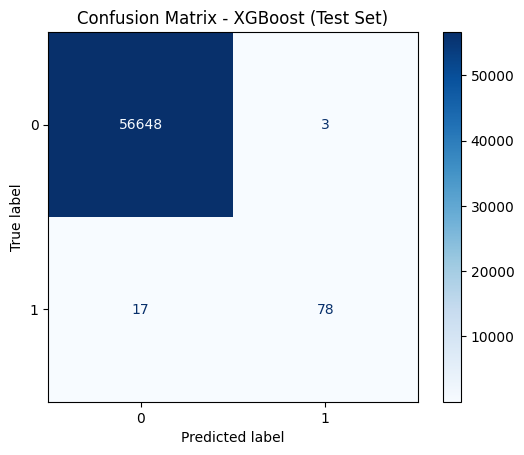

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - XGBoost (Test Set)")
plt.show()

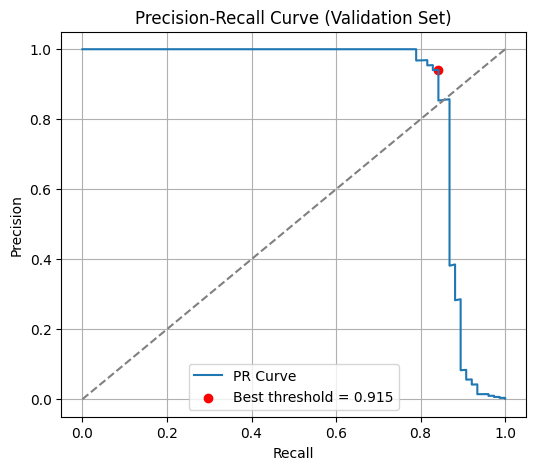

In [18]:
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label="PR Curve")

# Best threshold point
plt.scatter(
    recall[best_idx],
    precision[best_idx],
    color="red",
    label=f"Best threshold = {best_threshold:.3f}"
)

# y = x line (reference only)
x = np.linspace(0, 1, 100)
plt.plot(x, x, linestyle="--", color="gray")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation Set)")
plt.legend()
plt.grid()
plt.show()

# saving the model+threshold

In [ ]:
import joblib

joblib.dump(best_model, "../models/xgb_fraud_model.pkl")
joblib.dump(best_threshold, "../models/best_threshold.pkl")